In [1]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq
from difflib import SequenceMatcher

# ========== LOAD FASTA ==========
sequences = list(SeqIO.parse("vaccines_with_adjuvants.fasta", "fasta"))

# ========== CHECK FOR EXACT DUPLICATES ==========
unique_seqs = {}
for record in sequences:
    seq_str = str(record.seq)
    if seq_str not in unique_seqs:
        unique_seqs[seq_str] = [record.id]
    else:
        unique_seqs[seq_str].append(record.id)

duplicates = {k: v for k, v in unique_seqs.items() if len(v) > 1}
if duplicates:
    print("Found exact duplicates:")
    for seq, ids in duplicates.items():
        print(" -> ", ids)
else:
    print("✅ No exact duplicates found.")

# ========== CHECK FOR OVERLAPS (80%+) ==========
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

threshold = 0.80
overlapping_pairs = []

for i in range(len(sequences)):
    for j in range(i+1, len(sequences)):
        seq1 = str(sequences[i].seq)
        seq2 = str(sequences[j].seq)
        min_len = min(len(seq1), len(seq2))
        id1 = sequences[i].id
        id2 = sequences[j].id

        sim_score = similar(seq1, seq2)
        if sim_score >= threshold:
            overlapping_pairs.append((id1, id2, round(sim_score, 3)))

if overlapping_pairs:
    print("\n⚠️ Overlapping sequences (≥80%):")
    for p in overlapping_pairs:
        print(f"{p[0]} ↔ {p[1]} | Similarity: {p[2]}")
else:
    print("✅ No significantly overlapping sequences found.")


Found exact duplicates:
 ->  ['Vaccine5:', 'Vaccine6:']

⚠️ Overlapping sequences (≥80%):
Vaccine1: ↔ Vaccine4: | Similarity: 0.91
Vaccine1: ↔ Vaccine10: | Similarity: 0.847
Vaccine2: ↔ Vaccine3: | Similarity: 0.942
Vaccine4: ↔ Vaccine5: | Similarity: 0.81
Vaccine4: ↔ Vaccine6: | Similarity: 0.81
Vaccine4: ↔ Vaccine7: | Similarity: 0.806
Vaccine4: ↔ Vaccine8: | Similarity: 0.806
Vaccine4: ↔ Vaccine10: | Similarity: 0.898
Vaccine5: ↔ Vaccine6: | Similarity: 1.0
Vaccine5: ↔ Vaccine7: | Similarity: 0.806
Vaccine5: ↔ Vaccine8: | Similarity: 0.829
Vaccine6: ↔ Vaccine7: | Similarity: 0.806
Vaccine6: ↔ Vaccine8: | Similarity: 0.829
Vaccine7: ↔ Vaccine8: | Similarity: 0.916
Vaccine7: ↔ Vaccine10: | Similarity: 0.84
Vaccine8: ↔ Vaccine10: | Similarity: 0.837
Vaccine9: ↔ Vaccine10: | Similarity: 0.81


<Figure size 1000x600 with 0 Axes>

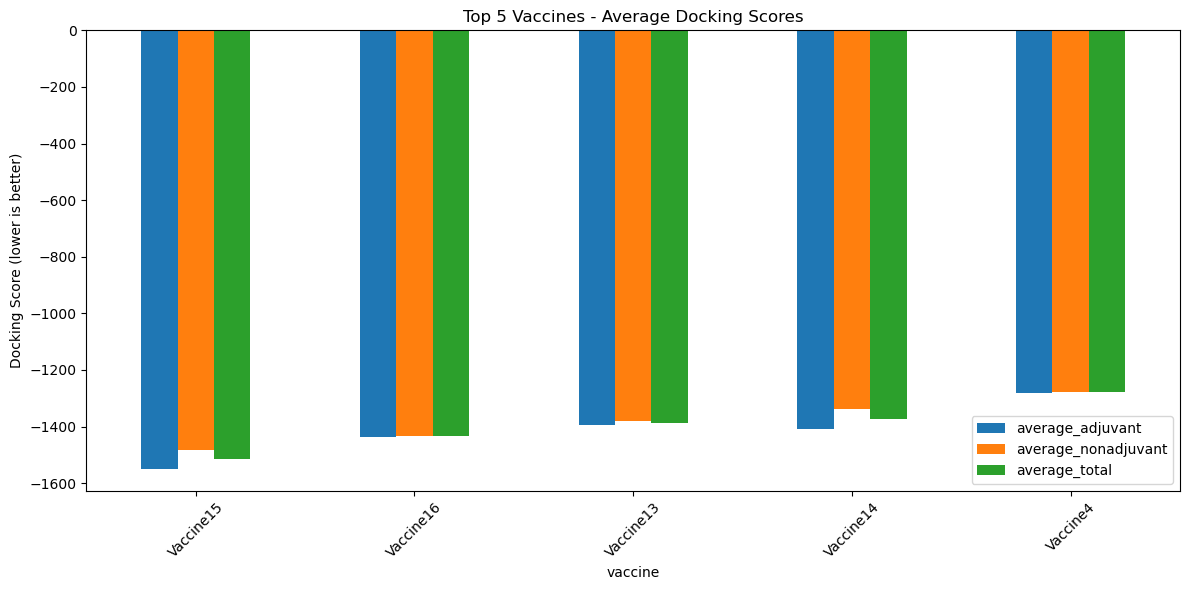

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ========== LOAD SCORES ==========
df = pd.read_csv('manuscript_ready_scores.csv')

# ========== CLEAN & COMPUTE AVERAGES ==========
df['average_adjuvant'] = df.filter(like='adjuvant_score').mean(axis=1)
df['average_nonadjuvant'] = df.filter(like='nonadjuvant_score').mean(axis=1)
df['average_total'] = df[['average_adjuvant', 'average_nonadjuvant']].mean(axis=1)

# ========== SELECT TOP 5 ==========
top5 = df.nsmallest(5, 'average_total')

# ========== SAVE TOP5 ==========
top5.to_csv('top5_vaccines.csv', index=False)

# ========== PLOT BARPLOT ==========
plt.figure(figsize=(10,6))
top5_plot = top5.set_index('vaccine')[['average_adjuvant', 'average_nonadjuvant', 'average_total']]
top5_plot.plot(kind='bar', figsize=(12,6))
plt.ylabel('Docking Score (lower is better)')
plt.title('Top 5 Vaccines - Average Docking Scores')
plt.xticks(rotation=45)
plt.tight_layout()

# Save with high resolution
plt.savefig('top5_vaccine_scores.png', dpi=600)

plt.show()

C:\Users\MHC V(D)J\AppData\Local\Temp\ipykernel_12992\1398505393.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x='vaccine', y='average_adjuvant', palette='Blues_d')


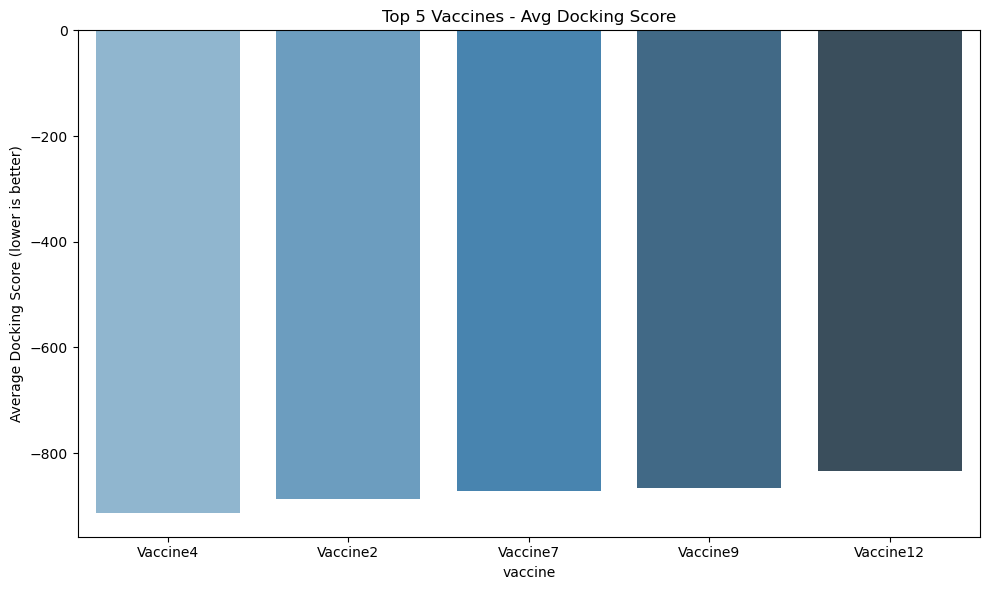

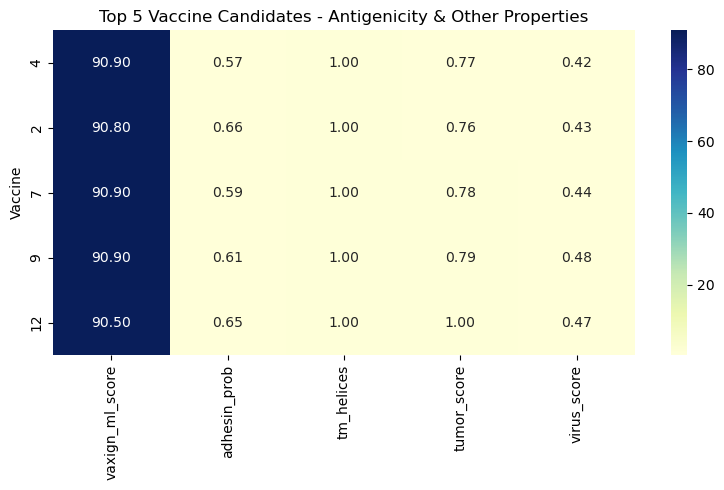

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------
# 1. LOAD DOCKING SCORES
# --------------------------
docking_data = [
    ("8WTA", "Vaccine15", -1613.449882), ("8WTA", "Vaccine14", -1477.196398),
    ("8WTA", "Vaccine16", -1437.750527), ("8WTA", "Vaccine13", -1409.846858),
    ("8WTA", "Vaccine4", -1283.26237),   ("8WTA", "Vaccine8", -1274.505883),
    ("8WTA", "Vaccine3", -1273.163492),  ("8WTA", "Vaccine10", -1272.336825),
    ("8WTA", "Vaccine2", -1259.651045),  ("8WTA", "Vaccine7", -1243.023583),
    ("8WTA", "Vaccine9", -1241.473197),  ("8WTA", "Vaccine6", -1236.460889),
    ("8WTA", "Vaccine5", -1216.499946),  ("8WTA", "Vaccine1", -1216.040622),
    ("8WTA", "Vaccine12", -1207.211369), ("7M8S", "Vaccine15", -1184.545849),
    ("3BIK", "Vaccine15", -1094.426452), ("7M8S", "Vaccine14", -1060.85778),
    ("7M8S", "Vaccine16", -1014.917958), ("7M8S", "Vaccine13", -1006.557267),
    ("1KCG", "Vaccine15", -1003.900558), ("3BIK", "Vaccine14", -968.879469),
    ("3BIK", "Vaccine16", -913.9858528), ("3BIK", "Vaccine13", -899.1989165),
    ("7M8S", "Vaccine4", -885.6527853),  ("1KCG", "Vaccine14", -875.7003959),
    ("7M8S", "Vaccine3", -875.6669687),  ("7M8S", "Vaccine10", -866.1254563),
    ("7M8S", "Vaccine8", -866.0060341),  ("7M8S", "Vaccine2", -847.915813),
    ("7M8S", "Vaccine7", -845.0987259),  ("7M8S", "Vaccine6", -838.3335425),
    ("7M8S", "Vaccine9", -834.3010148),  ("1KCG", "Vaccine16", -827.6384786),
    ("7M8S", "Vaccine11", -827.3290303), ("7M8S", "Vaccine5", -818.7317719),
    ("1KCG", "Vaccine13", -812.2736142), ("7M8S", "Vaccine1", -809.6322793),
    ("7M8S", "Vaccine12", -805.1464386), ("3BIK", "Vaccine4", -786.4347211),
    ("3BIK", "Vaccine3", -779.1254402),  ("3BIK", "Vaccine2", -767.3073555),
    ("3BIK", "Vaccine8", -762.9785884),  ("3BIK", "Vaccine10", -761.1522199),
    ("3BIK", "Vaccine7", -745.2676571),  ("3BIK", "Vaccine6", -742.6968583),
    ("3BIK", "Vaccine9", -734.8408432),  ("3BIK", "Vaccine11", -730.4516906),
    ("3BIK", "Vaccine5", -720.4852005),  ("3BIK", "Vaccine1", -711.7786914),
    ("3BIK", "Vaccine12", -706.3828746), ("1KCG", "Vaccine3", -698.0507551),
    ("1KCG", "Vaccine4", -695.2449553),  ("1KCG", "Vaccine10", -684.2668593),
    ("1KCG", "Vaccine8", -679.8173608),  ("1KCG", "Vaccine2", -670.6556724),
    ("1KCG", "Vaccine7", -656.4272164),  ("1KCG", "Vaccine6", -654.5734034),
    ("1KCG", "Vaccine9", -654.5463943),  ("1KCG", "Vaccine11", -643.1902236),
    ("1KCG", "Vaccine5", -633.3052268),  ("1KCG", "Vaccine1", -631.0027275),
    ("1KCG", "Vaccine12", -614.052861)
]

docking_df = pd.DataFrame(docking_data, columns=["receptor", "vaccine", "adjuvant_score"])
docking_df["vaccine"] = docking_df["vaccine"].str.strip().str.capitalize()

# Compute average docking score per vaccine
avg_docking = docking_df.groupby("vaccine", as_index=False).agg(average_adjuvant=("adjuvant_score", "mean"))

# --------------------------
# 2. Vaxign-ML and VaxiJen DATA
# --------------------------
vaxign_df = pd.DataFrame({
    'vaccine': [f'Vaccine{i}' for i in range(1, 17)],
    'vaxign_ml_score': [90.9, 90.8, 90.3, 90.9, 90.6, 90.8, 90.9, 90.9,
                        90.9, 90.9, 90.5, 90.5, 88.2, 88.8, 90.9, 90.9],
    'localization': ['membrane']*16,
    'adhesin_prob': [0.555, 0.661, 0.751, 0.573, 0.593, 0.593, 0.589, 0.549,
                     0.608, 0.585, 0.589, 0.650, 0.715, 0.647, 0.600, 0.617],
    'tm_helices': [1,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3]
})

vaxijen_df = pd.DataFrame({
    'vaccine': [f'Vaccine{i}' for i in range(1, 17)],
    'tumor_score': [0.8037, 0.7626, 0.7663, 0.7692, 0.7914, 0.7914, 0.7801, 0.8515,
                    0.7898, 0.7574, 0.8372, 0.9997, 0.5261, 0.5126, 0.4605, 0.4578],
    'tumor_prediction': ['Probable Antigen']*14 + ['Probable Non-Antigen']*2,
    'virus_score': [0.3469, 0.4279, 0.4211, 0.4212, 0.4108, 0.4108, 0.4427, 0.4354,
                    0.4817, 0.4058, 0.3750, 0.4686, 0.5234, 0.5190, 0.4304, 0.4279],
    'virus_prediction': ['Non-Antigen'] + ['Probable Antigen']*14 + ['Probable Antigen']
})

# --------------------------
# 3. MERGE AND FILTER
# --------------------------
merged = avg_docking.merge(vaxign_df, on='vaccine').merge(vaxijen_df, on='vaccine')

filtered = merged[
    (merged['vaxign_ml_score'] >= 90.5) &
    (merged['adhesin_prob'] >= 0.55) &
    (merged['localization'].str.contains('membrane|periplasmic', case=False)) &
    (merged['tm_helices'] <= 2) &
    (merged['tumor_score'] >= 0.75) &
    (merged['virus_score'] >= 0.42) &
    (merged['tumor_prediction'] == 'Probable Antigen') &
    (merged['virus_prediction'] == 'Probable Antigen')
]

# --------------------------
# 4. TOP 5 FINAL VACCINES
# --------------------------
top5 = filtered.nsmallest(5, 'average_adjuvant')
top5.to_csv("top5_final_vaccine_summary.csv", index=False)

# --------------------------
# 5. BARPLOT - Docking Scores
# --------------------------
plt.figure(figsize=(10,6))
sns.barplot(data=top5, x='vaccine', y='average_adjuvant', palette='Blues_d')
plt.ylabel('Average Docking Score (lower is better)')
plt.title('Top 5 Vaccines - Avg Docking Score')
plt.tight_layout()
plt.savefig('top5_avg_docking_scores.png', dpi=600)
plt.show()

# --------------------------
# 6. HEATMAP - Features
# --------------------------
# --------------------------
# 6. HEATMAP - Features
# --------------------------
# Remove 'Vaccine' prefix from row labels
heatmap_data = top5.set_index('vaccine')[['vaxign_ml_score', 'adhesin_prob', 'tm_helices',
                                          'tumor_score', 'virus_score']]
heatmap_data.index = heatmap_data.index.str.replace('Vaccine', '')

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f")
plt.ylabel('Vaccine')  # Set general y-axis label
plt.title('Top 5 Vaccine Candidates - Antigenicity & Other Properties')
plt.tight_layout()
plt.savefig('top5_vaccine_features_heatmap.png', dpi=600)
plt.show()
